In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

df['dropout'] = df['average_score'].apply(lambda x: 1 if x < 40 else 0)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("dropout", axis=1)
y = df["dropout"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.995
KNN Accuracy: 0.96
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0
Naive Bayes Accuracy: 0.925
SVM Accuracy: 0.97


In [ ]:
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=3)
    print(name, "Cross Validation Accuracy:", scores.mean())

Logistic Regression Cross Validation Accuracy: 0.993993993993994
KNN Cross Validation Accuracy: 0.9749959540378702
Decision Tree Cross Validation Accuracy: 1.0
Random Forest Cross Validation Accuracy: 0.998998998998999
Naive Bayes Cross Validation Accuracy: 0.8799937662213111
SVM Cross Validation Accuracy: 0.9839959720199242


In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[190   0]
 [  0  10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head())

           Feature  Importance
3    average_score    0.451471
1    reading score    0.219077
2    writing score    0.207705
0       math score    0.097285
14  lunch_standard    0.007225


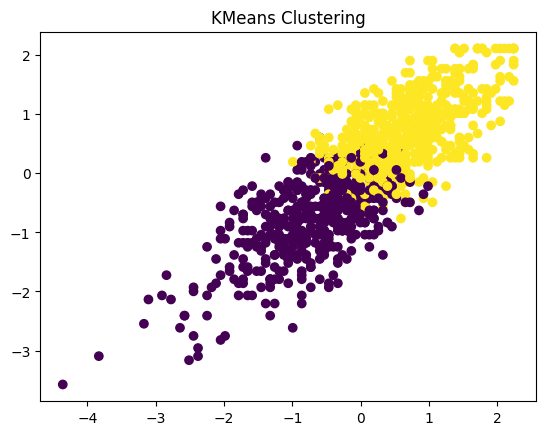

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("KMeans Clustering")
plt.show()

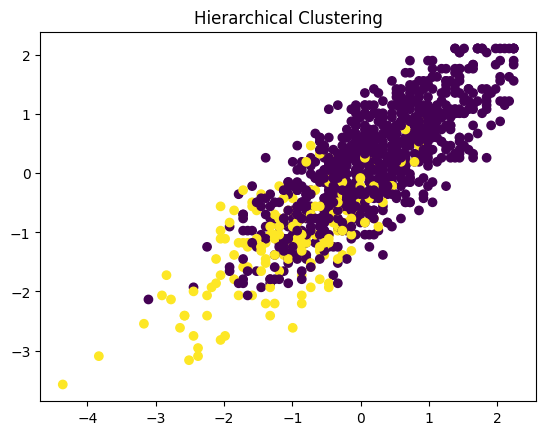

In [ ]:
hc = AgglomerativeClustering(n_clusters=2)
hc_labels = hc.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()

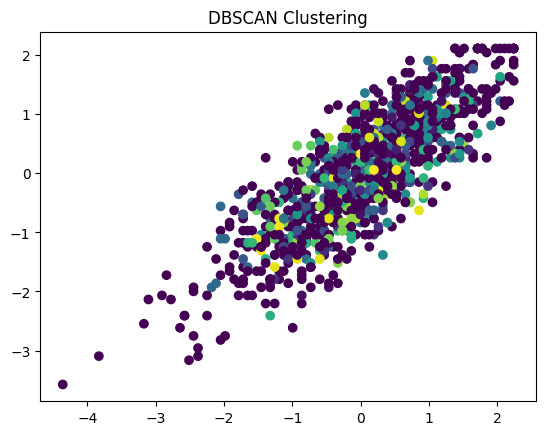

In [ ]:
db = DBSCAN(eps=1.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels)
plt.title("DBSCAN Clustering")
plt.show()